In [235]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [236]:
pd.set_option('display.max_columns', None)

In [237]:
df = pd.read_csv('D:/Desktop/movie-recommender-system/data/raw/movies_metadata.csv')
df.head(5)

C:\Users\mdwas\AppData\Local\Temp\ipykernel_17936\3654933237.py:1: DtypeWarning: Columns (0: popularity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('D:/Desktop/movie-recommender-system/data/raw/movies_metadata.csv')


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [238]:
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='str')

In [239]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  str    
 1   belongs_to_collection  4494 non-null   str    
 2   budget                 45466 non-null  str    
 3   genres                 45466 non-null  str    
 4   homepage               7782 non-null   str    
 5   id                     45466 non-null  str    
 6   imdb_id                45449 non-null  str    
 7   original_language      45455 non-null  str    
 8   original_title         45466 non-null  str    
 9   overview               44512 non-null  str    
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  str    
 12  production_companies   45463 non-null  str    
 13  production_countries   45463 non-null  str    
 14  release_date           45379 non-null  str    
 15  revenue      

In [240]:
df.shape

(45466, 24)

In [241]:
df.isnull().sum()

adult                        0
belongs_to_collection    40972
budget                       0
genres                       0
homepage                 37684
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64

<Axes: >

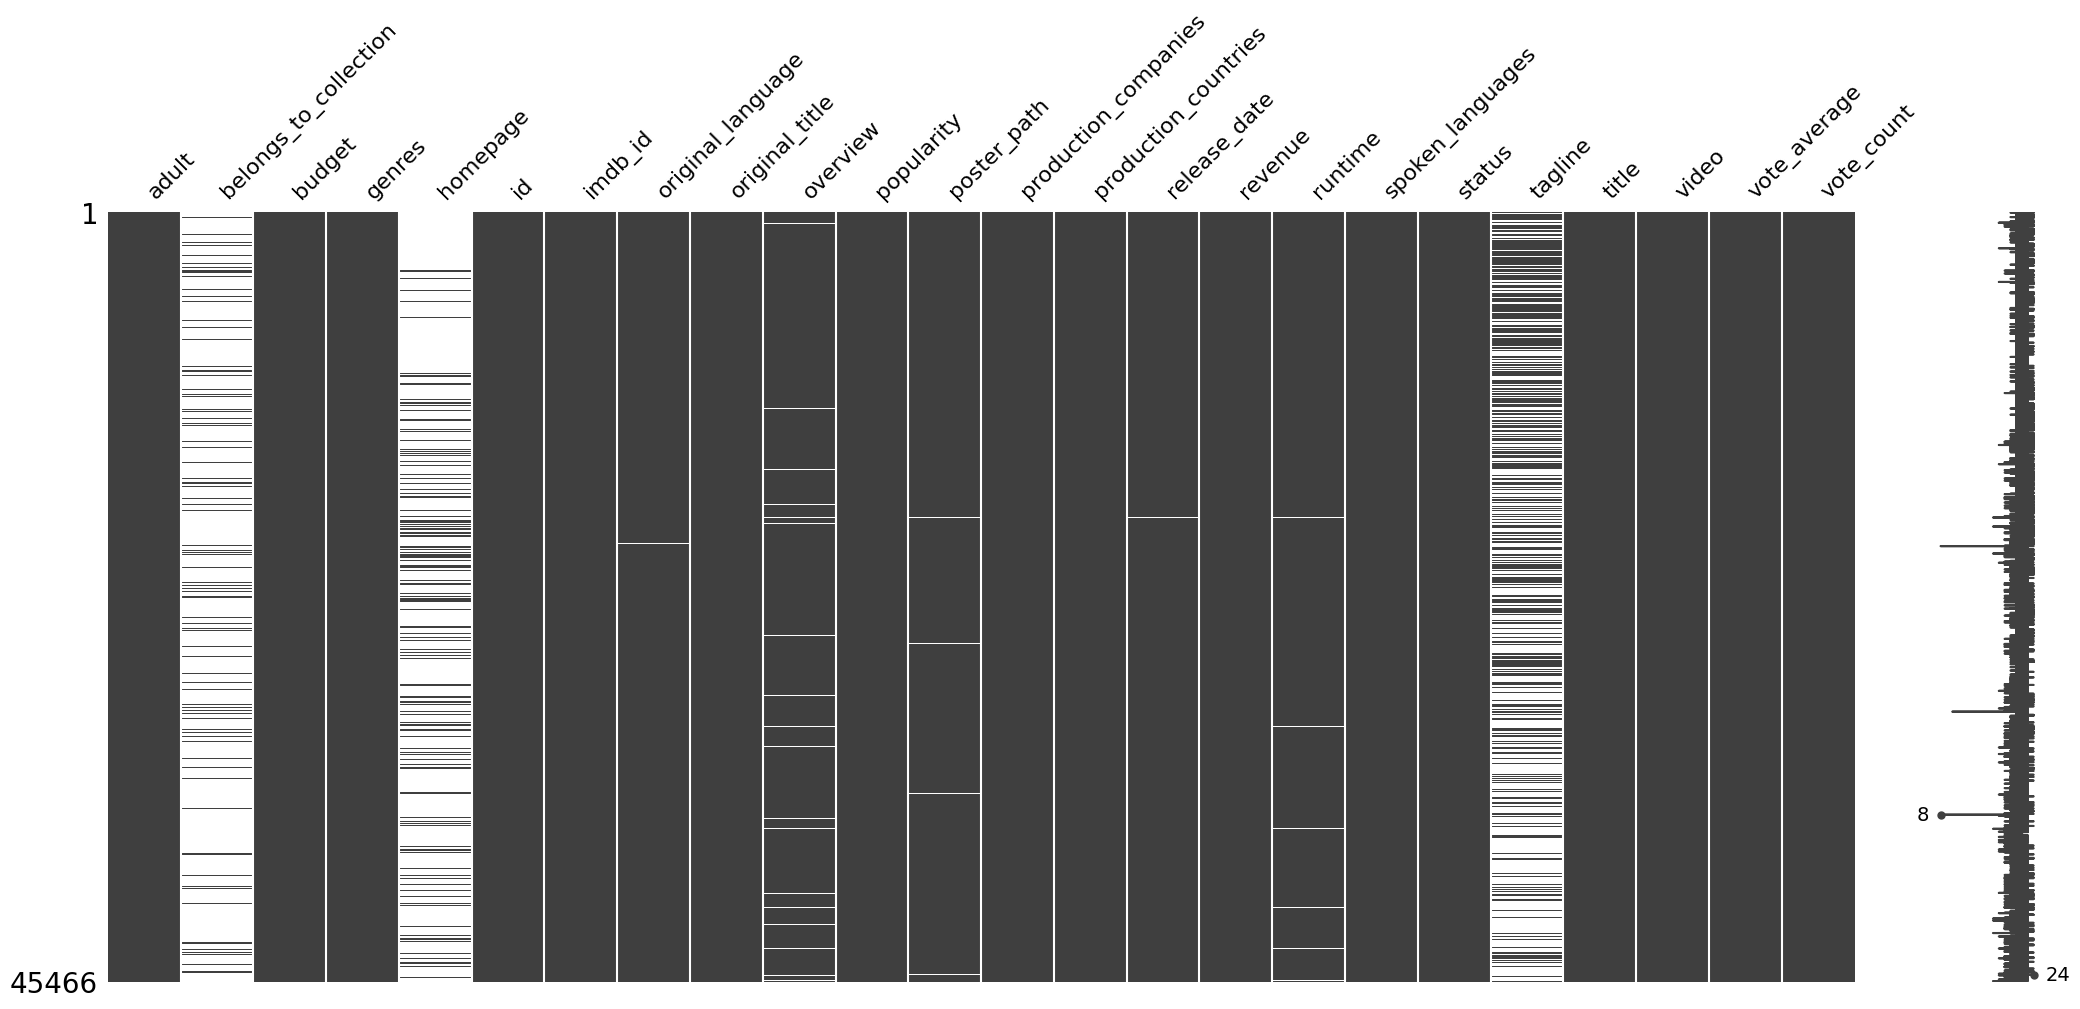

In [242]:
import missingno as msno
msno.matrix(df)

In [243]:
# droping columns with more than 50% missing values excpet tagline as i think it is important for content based filtering
df.drop(columns=['belongs_to_collection', 'homepage'], inplace=True)

In [244]:
df.duplicated().sum()

np.int64(13)

In [245]:
df = df.drop_duplicates().reset_index(drop = True)

In [246]:
df.assign(name=df['title'].str.strip().str.replace(' ', '').str.lower()).duplicated(subset=['name','release_date']).sum()

np.int64(19)

In [247]:
df['name']= df['original_title'].str.strip().str.replace(' ', '').str.lower()
df[df.duplicated(subset=['name','release_date'], keep=False)].sort_values(by=['name','release_date']).head(6)

,adult,budget,genres,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,name
949,False,4,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",22649,tt0022879,en,A Farewell to Arms,British nurse Catherine Barkley (Helen Hayes) ...,1.914697,/k0MF0IIbJ2PfOIku2KyraXL72d8.jpg,"[{'name': 'Paramount Pictures', 'id': 4}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1932-12-08,25.0,89.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Every woman who has loved will understand,A Farewell to Arms,False,6.2,29.0,afarewelltoarms
15070,False,4,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",22649,tt0022879,en,A Farewell to Arms,British nurse Catherine Barkley (Helen Hayes) ...,2.411191,/k0MF0IIbJ2PfOIku2KyraXL72d8.jpg,"[{'name': 'Paramount Pictures', 'id': 4}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1932-12-08,25.0,89.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Every woman who has loved will understand,A Farewell to Arms,False,6.2,29.0,afarewelltoarms
2563,False,0,"[{'id': 99, 'name': 'Documentary'}]",84198,tt1736049,en,A Place at the Table,"Using personal stories, this powerful document...",0.501046,/jn8L1QdWWX5c0NUOLjzaSXtZrbt.jpg,[],"[{'iso_3166_1': 'US', 'name': 'United States o...",2012-03-22,0.0,84.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,One Nation. Underfed.,A Place at the Table,False,6.9,7.0,aplaceatthetable
21111,False,0,"[{'id': 99, 'name': 'Documentary'}]",84198,tt1736049,en,A Place at the Table,"Using personal stories, this powerful document...",1.673307,/jn8L1QdWWX5c0NUOLjzaSXtZrbt.jpg,[],"[{'iso_3166_1': 'US', 'name': 'United States o...",2012-03-22,0.0,84.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,One Nation. Underfed.,A Place at the Table,False,6.9,7.0,aplaceatthetable
11152,False,40000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 18, '...",77221,tt1701210,en,Black Gold,"On the Arabian Peninsula in the 1930s, two war...",6.652197,/iQd7zWhSeCe3cgdPcLIDXjGfdzL.jpg,"[{'name': 'France 2 Cinéma', 'id': 83}, {'name...","[{'iso_3166_1': 'FR', 'name': 'France'}, {'iso...",2011-12-21,5446000.0,130.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Black Gold,False,5.9,77.0,blackgold
20838,False,40000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 18, '...",77221,tt1701210,en,Black Gold,"On the Arabian Peninsula in the 1930s, two war...",6.475665,/iQd7zWhSeCe3cgdPcLIDXjGfdzL.jpg,"[{'name': 'France 2 Cinéma', 'id': 83}, {'name...","[{'iso_3166_1': 'FR', 'name': 'France'}, {'iso...",2011-12-21,5446000.0,130.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Black Gold,False,5.9,77.0,blackgold


In [248]:
df.drop_duplicates(subset=['name','release_date'], keep='first', inplace=True)

In [249]:
df.reset_index(drop=True, inplace=True)

In [250]:
df.columns

Index(['adult', 'budget', 'genres', 'id', 'imdb_id', 'original_language',
       'original_title', 'overview', 'popularity', 'poster_path',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'video', 'vote_average', 'vote_count', 'name'],
      dtype='str')

In [251]:
# all columns are not needed for content based filtering i will only works with these columns
cols = ['original_title', 'overview', 'tagline', 'genres', 'vote_average', 'id']
df = df[cols]
df.head(5)


,original_title,overview,tagline,genres,vote_average,id
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",NaN,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",7.7,862
1,Jumanji,When siblings Judy and Peter discover an encha...,Roll the dice and unleash the excitement!,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6.9,8844
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Still Yelling. Still Fighting. Still Ready for...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",6.5,15602
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Friends are the people who let you be yourself...,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",6.1,31357
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Just When His World Is Back To Normal... He's ...,"[{'id': 35, 'name': 'Comedy'}]",5.7,11862


In [252]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45436 entries, 0 to 45435
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   original_title  45436 non-null  str    
 1   overview        44482 non-null  str    
 2   tagline         20401 non-null  str    
 3   genres          45436 non-null  str    
 4   vote_average    45430 non-null  float64
 5   id              45436 non-null  str    
dtypes: float64(1), str(5)
memory usage: 2.1 MB


In [253]:
df.isna().sum()

original_title        0
overview            954
tagline           25035
genres                0
vote_average          6
id                    0
dtype: int64

In [254]:
df['overview']=df['overview'].fillna('')
df['tagline']=df['tagline'].fillna('') 
df['vote_average']=df['vote_average'].fillna(df['vote_average'].mean())



In [255]:
df

,original_title,overview,tagline,genres,vote_average,id
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",7.7,862
1,Jumanji,When siblings Judy and Peter discover an encha...,Roll the dice and unleash the excitement!,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6.9,8844
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Still Yelling. Still Fighting. Still Ready for...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",6.5,15602
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Friends are the people who let you be yourself...,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",6.1,31357
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Just When His World Is Back To Normal... He's ...,"[{'id': 35, 'name': 'Comedy'}]",5.7,11862
...,...,...,...,...,...,...
45431,رگ خواب,Rising and falling between a man and woman.,Rising and falling between a man and woman,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",4.0,439050
45432,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,,"[{'id': 18, 'name': 'Drama'}]",9.0,111109
45433,Betrayal,"When one of her hits goes wrong, a professiona...",A deadly game of wits.,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",3.8,67758
45434,Satana likuyushchiy,"In a small town live two brothers, one a minis...",,[],0.0,227506


In [256]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45436 entries, 0 to 45435
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   original_title  45436 non-null  str    
 1   overview        45436 non-null  str    
 2   tagline         45436 non-null  str    
 3   genres          45436 non-null  str    
 4   vote_average    45436 non-null  float64
 5   id              45436 non-null  str    
dtypes: float64(1), str(5)
memory usage: 2.1 MB


In [257]:
dff=pd.read_csv('D:/Desktop/movie-recommender-system/data/processed/movies_metadata_processed.csv')
dff.info()

<class 'pandas.DataFrame'>
RangeIndex: 45436 entries, 0 to 45435
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   original_title  45436 non-null  str    
 1   overview        45436 non-null  str    
 2   tagline         45436 non-null  str    
 3   genres          45436 non-null  str    
 4   vote_average    45436 non-null  float64
 5   id              45436 non-null  str    
dtypes: float64(1), str(5)
memory usage: 2.1 MB


In [258]:
df['genres'] = df['genres'].apply(lambda x: ' '.join([i['name'] for i in eval(x)]) if pd.notnull(x) else '')
df.head(5)

,original_title,overview,tagline,genres,vote_average,id
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",,Animation Comedy Family,7.7,862
1,Jumanji,When siblings Judy and Peter discover an encha...,Roll the dice and unleash the excitement!,Adventure Fantasy Family,6.9,8844
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Still Yelling. Still Fighting. Still Ready for...,Romance Comedy,6.5,15602
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Friends are the people who let you be yourself...,Comedy Drama Romance,6.1,31357
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Just When His World Is Back To Normal... He's ...,Comedy,5.7,11862


In [259]:
# combined_features column will created by combining overview, tagline, genres and production_companies columns
df['combined_features'] = df['overview'] + ' ' + df['tagline'] + ' ' + df['genres'] 
df=df[['original_title', 'combined_features', 'vote_average','id']]
df.head(5)

,original_title,combined_features,vote_average,id
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",7.7,862
1,Jumanji,When siblings Judy and Peter discover an encha...,6.9,8844
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,6.5,15602
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",6.1,31357
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,5.7,11862


# remove
1. punchuation
2. stopwords
3. lemmatization
4. 

In [260]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45436 entries, 0 to 45435
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   original_title     45436 non-null  str    
 1   combined_features  45436 non-null  str    
 2   vote_average       45436 non-null  float64
 3   id                 45436 non-null  str    
dtypes: float64(1), str(3)
memory usage: 1.4 MB


In [261]:
import nltk 
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mdwas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mdwas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mdwas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [262]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
df

,original_title,combined_features,vote_average,id
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",7.7,862
1,Jumanji,When siblings Judy and Peter discover an encha...,6.9,8844
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,6.5,15602
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",6.1,31357
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,5.7,11862
...,...,...,...,...
45431,رگ خواب,Rising and falling between a man and woman. Ri...,4.0,439050
45432,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,9.0,111109
45433,Betrayal,"When one of her hits goes wrong, a professiona...",3.8,67758
45434,Satana likuyushchiy,"In a small town live two brothers, one a minis...",0.0,227506


In [263]:

import string
import re

def preprocess_text(text):
    text = str(text.lower())
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words and w not in string.punctuation]
    tokens = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(tokens)


df['combined_features'] = df['combined_features'].apply(preprocess_text)
df.head(5)

,original_title,combined_features,vote_average,id
0,Toy Story,led woody andys toy live happily room andys bi...,7.7,862
1,Jumanji,sibling judy peter discover enchanted board ga...,6.9,8844
2,Grumpier Old Men,family wedding reignites ancient feud nextdoor...,6.5,15602
3,Waiting to Exhale,cheated mistreated stepped woman holding breat...,6.1,31357
4,Father of the Bride Part II,george bank recovered daughter wedding receive...,5.7,11862


In [264]:
df=pd.read_csv('D:/Desktop/movie-recommender-system/data/processed/features_data.csv')
df.head(5)

,original_title,combined_features,vote_average,id
0,Toy Story,led woody andys toy live happily room andys bi...,7.7,862
1,Jumanji,sibling judy peter discover enchanted board ga...,6.9,8844
2,Grumpier Old Men,family wedding reignites ancient feud nextdoor...,6.5,15602
3,Waiting to Exhale,cheated mistreated stepped woman holding breat...,6.1,31357
4,Father of the Bride Part II,george bank recovered daughter wedding receive...,5.7,11862


In [265]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45176 entries, 0 to 45175
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   original_title     45176 non-null  str    
 1   combined_features  45176 non-null  str    
 2   vote_average       45176 non-null  float64
 3   id                 45176 non-null  str    
dtypes: float64(1), str(3)
memory usage: 1.4 MB


In [266]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
tfidf = TfidfVectorizer(max_features=50000,ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(df['combined_features'])


In [267]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1711813 stored elements and shape (45176, 50000)>

In [268]:
top20Movies = df.sort_values('vote_average', ascending=False)['original_title'].head(20)
top20Movies

16652                                     My Foolish Heart
16646                        The Misadventures of Margaret
45081                LEGO DC Super Hero Girls: Brain Drain
42349     Frankie Boyle: Hurt Like You've Never Been Loved
42347                       Stephen Lynch: Hello Kalamazoo
39110                                  Survive and Advance
28304                                      Nocturne Indien
43369                                      The Reagan Show
38925                                        Truckfighters
38848    Old Fashioned: The Story of the Wisconsin Supp...
23517                                           Tall Story
20153                                   Road to Redemption
39407                                    The Far Pavilions
28047                                       Goodbye & Amen
39443                                             李三腳威震地獄門
1757                                 Dancer, Texas Pop. 81
23769                                   Slaying the Badg

In [269]:
# import random
df['name']= df['original_title'].str.strip().str.replace(' ', '').str.lower()
indices = pd.Series(df.index, index=df['name'])
indices = indices[~indices.index.duplicated(keep='first')]

li = top20Movies.tolist()
def recommend_movies(title,n=10):
    title = title.strip().replace(' ', '').lower()
    if title not in indices:
        return "no data"
    
    idx = indices[title]
    
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    sim_idx = sim_scores.argsort()[::-1][1:n+1]
    return df['original_title'].iloc[sim_idx]

In [270]:
recommend_movies('thedark knight')

18200                                The Dark Knight Rises
150                                         Batman Forever
1325                                        Batman Returns
34617                                         İtirazım Var
20176              Batman: The Dark Knight Returns, Part 2
25288                    Ritornano quelli della calibro 38
21127    Batman Unmasked: The Psychology of the Dark Kn...
40724    LEGO DC Comics Super Heroes: Batman: Be-Leaguered
43097                                   Mord in Eberswalde
15483                           Batman: Under the Red Hood
Name: original_title, dtype: str

In [271]:
# import pickle
# pickle.dump(tfidf_matrix, open('tfidf_matrix.pkl', 'wb'))
# pickle.dump(indices, open('df.pkl', 'wb'))
# df.to_pickle('df.pkl')
# pickle.dump(tfidf, open('tfidf.pkl', 'wb'))

In [272]:
df=pd.read_csv('D:/Desktop/movie-recommender-system/data/processed/movies_metadata_processed.csv')
df.head(2)

,original_title,overview,tagline,genres,vote_average,id
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",7.7,862
1,Jumanji,When siblings Judy and Peter discover an encha...,Roll the dice and unleash the excitement!,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6.9,8844


In [273]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45436 entries, 0 to 45435
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   original_title  45436 non-null  str    
 1   overview        45436 non-null  str    
 2   tagline         45436 non-null  str    
 3   genres          45436 non-null  str    
 4   vote_average    45436 non-null  float64
 5   id              45436 non-null  str    
dtypes: float64(1), str(5)
memory usage: 2.1 MB


In [274]:
df=pd.read_csv('D:/Desktop/movie-recommender-system/data/processed/features_data.csv')
df.head(2)

,original_title,combined_features,vote_average,id
0,Toy Story,led woody andys toy live happily room andys bi...,7.7,862
1,Jumanji,sibling judy peter discover enchanted board ga...,6.9,8844


In [275]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45176 entries, 0 to 45175
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   original_title     45176 non-null  str    
 1   combined_features  45176 non-null  str    
 2   vote_average       45176 non-null  float64
 3   id                 45176 non-null  str    
dtypes: float64(1), str(3)
memory usage: 1.4 MB
